# Análisis Exploratorio de Datos — Remesas de El Salvador

**Maestría en Análisis y Visualización de Datos Masivos - Universidad Internacional de La Rioja**

**Proyecto:** Predicción del volumen mensual de remesas familiares hacia El Salvador mediante modelos de machine learning e identificación de factores macroeconómicos determinantes (1991-2025).

**Período de análisis:** enero de 1991 – diciembre de 2025
 
**Equipo:** 1B
- Kelly Mabel Vílchez González
- Herbert Fernando Ramírez Aguilar

Este notebook desarrolla el análisis exploratorio del dataset maestro utilizado en el experimento. Se examinan la evolución temporal de las remesas, sus patrones de tendencia y de estacionalidad, las relaciones entre variables, la estructura de autocorrelación y las propiedades de estacionariedad de las series.

**Dataset analizado:** `Dataset_Maestro_Final.csv`

El archivo corresponde al dataset maestro utilizado en las etapas de análisis y modelado del proyecto, lo que permite mantener la coherencia y la trazabilidad entre las distintas fases del flujo metodológico.

In [2]:
# ============================================================
# 1. IMPORTACIÓN DE LIBRERÍAS Y CONFIGURACIÓN
# ============================================================
# Se importan las librerías requeridas para la manipulación,
# visualización y análisis estadístico de los datos.
# Centralizar las dependencias facilita la lectura y
# reproducibilidad del flujo de análisis.
# ============================================================

# --- Manipulación y cálculo de datos ---
import pandas as pd
# pandas: librería principal para trabajar con tablas de datos.
# Permite cargar, limpiar, transformar y exportar datos.
# Su estructura principal es el DataFrame (tabla de filas y columnas).

import numpy as np
# numpy: librería para operaciones matemáticas y arreglos numéricos.
# Se usa para cálculos como promedios, desviaciones y operaciones matriciales.

# --- Visualización ---
import matplotlib.pyplot as plt
# matplotlib: librería base para crear gráficos en Python.
# plt es el módulo de interfaz principal para dibujar figuras.

import matplotlib.dates as mdates
# mdates: módulo de matplotlib para formatear fechas en los ejes de los gráficos.

import seaborn as sns
# seaborn: librería de visualización estadística construida sobre matplotlib.
# Genera gráficos más estéticos con menos código.
# Especialmente útil para heatmaps y distribuciones.

# --- Estadística y análisis de series de tiempo ---
from statsmodels.tsa.seasonal import seasonal_decompose
# seasonal_decompose: función que descompone una serie de tiempo en:
# Tendencia + Estacionalidad + Residuos

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
# plot_acf: grafica la Función de Autocorrelación (ACF)
# Mide cuánto se relaciona la serie con sus propios valores pasados.
# plot_pacf: grafica la Autocorrelación Parcial (PACF)
# Mide la correlación directa con cada rezago eliminando efectos intermedios.

from statsmodels.tsa.stattools import adfuller
# adfuller: prueba estadística de Dickey-Fuller Aumentada.
# Se usa para verificar si una serie de tiempo es estacionaria.
# En términos generales, una serie estacionaria mantiene propiedades
# estadísticas relativamente estables a lo largo del tiempo.

from scipy import stats
# stats: módulo con funciones estadísticas de scipy.
# Se usará para pruebas de normalidad y análisis de distribuciones.

# --- Configuración global de visualizaciones ---
plt.rcParams['figure.figsize'] = (14, 5)
# Tamaño por defecto de todos los gráficos: 14 pulgadas de ancho x 5 de alto.

plt.rcParams['font.size'] = 11
# Tamaño de fuente base para todos los textos en los gráficos.

plt.rcParams['axes.grid'] = True
# Activa la cuadrícula en todos los gráficos automáticamente.

plt.rcParams['grid.alpha'] = 0.3
# Transparencia de la cuadrícula: 0 = invisible, 1 = sólida.
# 0.3 da una cuadrícula suave que no distrae.

sns.set_style("whitegrid")
# Estilo visual de seaborn: fondo blanco con cuadrícula gris suave.

# --- Suprimir advertencias menores ---
import warnings
warnings.filterwarnings('ignore')
# Oculta advertencias de versiones o deprecaciones que no afectan los resultados.

%matplotlib inline
# Esta línea le indica a Jupyter que muestre los gráficos
# directamente dentro del notebook y no en una ventana separada.

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


In [3]:
# ============================================================
# 2. CONFIGURACIÓN DE RUTAS Y CARPETA DE SALIDAS DEL EDA
# ============================================================
# Esta celda localiza la raíz del proyecto y define las rutas
# utilizadas para acceder al dataset maestro y guardar los
# gráficos y tablas generados durante el EDA.
#
# Funciona si el notebook se ejecuta desde la carpeta raíz
# del proyecto o desde la carpeta notebooks/.
# ============================================================

from pathlib import Path

# Obtener el directorio de trabajo actual.
CWD = Path.cwd()

# Detectar la raíz del proyecto.
if (
    (CWD / 'data').exists()
    and (CWD / 'notebooks').exists()
):
    PROJECT_ROOT = CWD

elif (
    (CWD.parent / 'data').exists()
    and (CWD.parent / 'notebooks').exists()
):
    PROJECT_ROOT = CWD.parent

else:
    raise FileNotFoundError(
        "No se pudo localizar la raíz del proyecto. "
        "Se esperaban las carpetas 'data' y 'notebooks'."
    )

# Definir las rutas principales.
DATA_DIR = PROJECT_ROOT / 'data'
OUTPUTS_EDA = PROJECT_ROOT / 'outputs_eda'

# Crear automáticamente la carpeta de salidas del EDA.
OUTPUTS_EDA.mkdir(
    parents=True,
    exist_ok=True
)

# Verificación de rutas.
print("=== CONFIGURACIÓN DE RUTAS ===")
print(f"Raíz del proyecto   : {PROJECT_ROOT}")
print(f"Directorio de datos : {DATA_DIR}")
print(f"Salidas del EDA     : {OUTPUTS_EDA}")

=== CONFIGURACIÓN DE RUTAS ===
Raíz del proyecto   : C:\Users\kmabe\TFM
Directorio de datos : C:\Users\kmabe\TFM\data
Salidas del EDA     : C:\Users\kmabe\TFM\outputs_eda


In [4]:
# ============================================================
# 3. CARGA DEL DATASET MAESTRO
# ============================================================
# Se carga el archivo CSV que integra las fuentes de datos
# utilizadas en el proyecto: BCR de El Salvador, FRED,
# Banco Mundial y DHS.
#
# IMPORTANTE: en la estructura actual, el archivo
# Dataset_Maestro_Final.csv debe estar en la misma carpeta
# que este notebook.
# ============================================================

df = pd.read_csv(
    DATA_DIR / 'Dataset_Maestro_Final.csv',
    index_col='Fecha',
    parse_dates=True
)

# read_csv: carga el archivo CSV y lo convierte en un DataFrame.
# parse_dates=['Fecha']: indica a pandas que la columna 'Fecha'
#   debe interpretarse como fecha (datetime), no como texto.
#   Esto permite realizar operaciones propias de series temporales.
# index_col='Fecha': establece la columna 'Fecha' como índice del DataFrame.
#   Esto facilita agrupaciones, filtros y operaciones basadas en fechas.

# --- Verificar dimensiones del dataset ---
print("=== DIMENSIONES DEL DATASET ===")
print(f"Filas    : {df.shape[0]}")
# df.shape devuelve una tupla (filas, columnas).
# df.shape[0] = número de filas = número de meses en el dataset.

print(f"Columnas : {df.shape[1]}")
# df.shape[1] = número de columnas = número de variables.

# --- Ver las primeras filas ---
print("\n=== PRIMERAS 5 FILAS ===")
display(df.head())
# head() muestra las primeras 5 filas por defecto.
# Permite verificar la carga inicial y el formato temporal del índice.

# --- Ver las últimas filas ---
print("\n=== ÚLTIMAS 5 FILAS ===")
display(df.tail())
# tail() muestra las últimas 5 filas.
# Permite verificar que la serie llega hasta diciembre de 2025.

# --- Ver tipos de datos ---
print("\n=== TIPOS DE DATOS POR COLUMNA ===")
display(df.dtypes)
# dtypes muestra el tipo de dato de cada columna.
# Las variables numéricas deben aparecer como float64 o int64.

=== DIMENSIONES DEL DATASET ===
Filas    : 420
Columnas : 15

=== PRIMERAS 5 FILAS ===


,Remesas_Millones_USD,Remesas_Lag1,Remesas_Lag2,Remesas_Lag3,Remesas_Lag12,Desempleo_Hispano_US,Desempleo_General_US,Salario_Promedio_US,Inflacion_CPI_US,PIB_US,Inflacion_ES,PIB_ES,Deportaciones_Total,Dummy_Crisis,Dummy_Covid
Fecha,,,,,,,,,,,,,,,
1991-01-01,63.1,NaN,NaN,NaN,NaN,9.1,6.4,10.37,134.7,6035.178,14.402675,5.252342e+09,NaN,0,0
1991-02-01,58.4,63.1,NaN,NaN,NaN,9.2,6.6,10.39,134.8,6035.178,14.402675,5.252342e+09,NaN,0,0
1991-03-01,67.6,58.4,63.1,NaN,NaN,9.8,6.8,10.41,134.8,6035.178,14.402675,5.252342e+09,NaN,0,0
1991-04-01,77.8,67.6,58.4,63.1,NaN,9.8,6.7,10.46,135.1,6126.862,14.402675,5.252342e+09,NaN,0,0
1991-05-01,77.4,77.8,67.6,58.4,NaN,10.0,6.9,10.50,135.6,6126.862,14.402675,5.252342e+09,NaN,0,0



=== ÚLTIMAS 5 FILAS ===


,Remesas_Millones_USD,Remesas_Lag1,Remesas_Lag2,Remesas_Lag3,Remesas_Lag12,Desempleo_Hispano_US,Desempleo_General_US,Salario_Promedio_US,Inflacion_CPI_US,PIB_US,Inflacion_ES,PIB_ES,Deportaciones_Total,Dummy_Crisis,Dummy_Covid
Fecha,,,,,,,,,,,,,,,
2025-08-01,824.96,872.89,865.38,899.08,709.06,5.3,4.3,31.49,323.291,31098.027,0.257571,3.670811e+10,NaN,0,0
2025-09-01,819.74,824.96,872.89,865.38,683.14,5.5,4.4,31.56,324.245,31098.027,0.257571,3.670811e+10,NaN,0,0
2025-10-01,852.99,819.74,824.96,872.89,732.41,5.5,4.4,31.70,324.245,31422.526,0.257571,3.670811e+10,NaN,0,0
2025-11-01,814.82,852.99,819.74,824.96,706.33,5.0,4.5,31.79,325.063,31422.526,0.257571,3.670811e+10,NaN,0,0
2025-12-01,961.12,814.82,852.99,819.74,832.73,4.9,4.4,31.83,326.031,31422.526,0.257571,3.670811e+10,NaN,0,0



=== TIPOS DE DATOS POR COLUMNA ===


Remesas_Millones_USD    float64
Remesas_Lag1            float64
Remesas_Lag2            float64
Remesas_Lag3            float64
Remesas_Lag12           float64
Desempleo_Hispano_US    float64
Desempleo_General_US    float64
Salario_Promedio_US     float64
Inflacion_CPI_US        float64
PIB_US                  float64
Inflacion_ES            float64
PIB_ES                  float64
Deportaciones_Total     float64
Dummy_Crisis              int64
Dummy_Covid               int64
dtype: object

In [5]:
# ============================================================
# 4. IMPUTACIÓN DE VALORES FALTANTES EN DEPORTACIONES_TOTAL
# ============================================================
# La variable Deportaciones_Total presenta 48 valores faltantes
# fuera del período cubierto por la serie DHS utilizada:
#   - 1991: 12 observaciones mensuales.
#   - 2023, 2024 y 2025: 36 observaciones mensuales.
#
# Para completar la variable antes del análisis exploratorio,
# se aplican los supuestos de imputación definidos en la
# metodología del proyecto.
# ============================================================

# --- Crear columna auxiliar con el año ---
df['Año'] = df.index.year
# df.index.year extrae el año de cada fecha del índice.
# Se guarda como columna auxiliar para facilitar el filtrado.

# --- CASO 1: AÑO 1991 ---
# Ante la ausencia de datos para 1991, se utiliza como aproximación
# la media mensual de 1992, primer año disponible en la serie DHS
# integrada al dataset.
valor_1992 = df[df['Año'] == 1992]['Deportaciones_Total'].mean()
# df[df['Año'] == 1992]: filtra solo las filas del año 1992.
# ['Deportaciones_Total']: selecciona esa columna específica.
# .mean(): calcula el promedio de los 12 valores mensuales
# disponibles para 1992.

print(f"Valor imputado para 1991: {valor_1992:.0f} deportaciones/mes")

df.loc[df['Año'] == 1991, 'Deportaciones_Total'] = valor_1992
# .loc[condición, columna]: selecciona las filas que cumplen
# la condición y asigna el valor imputado.

# --- CASO 2: AÑOS 2023, 2024 Y 2025 ---
# Para los años posteriores al último período cubierto por la
# serie DHS utilizada, se emplea como aproximación la media de
# los valores mensuales disponibles entre 2020 y 2022.
#
# Este supuesto evita extrapolar una tendencia no observada
# más allá de la cobertura de la fuente integrada.
media_reciente = df[
    df['Año'].isin([2020, 2021, 2022])
]['Deportaciones_Total'].mean()
# .isin([2020, 2021, 2022]): filtra las observaciones de esos años.
# .mean(): calcula el promedio de los valores mensuales combinados
# correspondientes al período 2020–2022.

print(
    f"Valor imputado para 2023-2025: "
    f"{media_reciente:.0f} deportaciones/mes"
)

df.loc[
    df['Año'].isin([2023, 2024, 2025]),
    'Deportaciones_Total'
] = media_reciente

# --- Eliminar columna auxiliar ---
df = df.drop(columns=['Año'])
# drop: elimina la columna auxiliar 'Año', que ya no se necesita.

# --- Verificar resultado ---
faltantes = df['Deportaciones_Total'].isnull().sum()
# isnull(): identifica los valores faltantes.
# .sum(): cuenta cuántos faltantes permanecen en la variable.

print(
    f"\nFaltantes restantes en Deportaciones_Total: "
    f"{faltantes}"
)
print("Imputación completada correctamente.")

Valor imputado para 1991: 2033 deportaciones/mes
Valor imputado para 2023-2025: 6688 deportaciones/mes

Faltantes restantes en Deportaciones_Total: 0
Imputación completada correctamente.


In [6]:
# ============================================================
# 5. VERIFICACIÓN GENERAL DE VALORES FALTANTES
# ============================================================
# Antes de continuar con el análisis, se verifica la presencia
# de valores faltantes (NaN) en el dataset.
#
# Tras la imputación de Deportaciones_Total, los faltantes
# restantes corresponden a los rezagos de remesas y son
# estructurales: al inicio de la serie no existe suficiente
# historial previo para calcular cada variable rezagada.
# ============================================================

# --- Contar faltantes por columna ---
nulos = df.isnull().sum()
# isnull(): genera una tabla de True/False (True = faltante).
# .sum(): suma los True por columna = cantidad de faltantes.

# --- Calcular porcentaje de faltantes ---
porcentaje = (nulos / len(df) * 100).round(2)
# len(df): número total de filas del dataset.
# Se divide la cantidad de nulos entre el total y se multiplica por 100.

# --- Construir tabla resumen ---
resumen_nulos = pd.DataFrame({
    'Valores faltantes': nulos,
    'Porcentaje (%)': porcentaje
})
# pd.DataFrame: crea una tabla con dos columnas a partir de los resultados.

print("=== VALORES FALTANTES POR VARIABLE ===")

print("\nVariables con faltantes:")
display(
    resumen_nulos[
        resumen_nulos['Valores faltantes'] > 0
    ]
)
# Filtra y muestra solo las variables que tienen al menos un faltante.

print("\nVariables completas (sin faltantes):")
completas = resumen_nulos[
    resumen_nulos['Valores faltantes'] == 0
].index.tolist()
# .index.tolist(): obtiene los nombres de las variables
# sin faltantes como lista.

for var in completas:
    print(f"  ✓ {var}")

print("\nNota: los faltantes en las variables Remesas_Lag son estructurales.")
print(
    "Al inicio de la serie no existe suficiente historial previo "
    "para calcular cada rezago."
)
print(
    "Estos registros se tratan posteriormente durante la "
    "preparación de los datos para el modelado."
)

=== VALORES FALTANTES POR VARIABLE ===

Variables con faltantes:


,Valores faltantes,Porcentaje (%)
Remesas_Lag1,1,0.24
Remesas_Lag2,2,0.48
Remesas_Lag3,3,0.71
Remesas_Lag12,12,2.86



Variables completas (sin faltantes):
  ✓ Remesas_Millones_USD
  ✓ Desempleo_Hispano_US
  ✓ Desempleo_General_US
  ✓ Salario_Promedio_US
  ✓ Inflacion_CPI_US
  ✓ PIB_US
  ✓ Inflacion_ES
  ✓ PIB_ES
  ✓ Deportaciones_Total
  ✓ Dummy_Crisis
  ✓ Dummy_Covid

Nota: los faltantes en las variables Remesas_Lag son estructurales.
Al inicio de la serie no existe suficiente historial previo para calcular cada rezago.
Estos registros se tratan posteriormente durante la preparación de los datos para el modelado.


In [7]:
# ============================================================
# 6. EDA — RESUMEN ESTADÍSTICO
# ============================================================
# El resumen estadístico ofrece una descripción numérica de
# cada variable y permite examinar tendencia central, dispersión,
# rangos y posibles valores extremos antes de profundizar en
# las visualizaciones y relaciones entre variables.
#
# Se incluyen media, mediana, desviación estándar, mínimo,
# máximo y percentiles 25%, 50% y 75%.
# ============================================================

# --- Calcular estadísticos con percentiles específicos ---
estadisticos = df.describe(
    percentiles=[0.25, 0.50, 0.75]
).T
# describe(): calcula automáticamente los estadísticos principales.
# percentiles=[0.25, 0.50, 0.75]: incluye Q1, mediana (Q2) y Q3.
# .T: transpone la tabla para que las variables sean filas
#     y los estadísticos sean columnas, facilitando su lectura.

# --- Renombrar columnas al español ---
estadisticos.columns = [
    'Conteo',         # Número de observaciones no nulas
    'Media',          # Promedio aritmético de los valores
    'Desv. Estándar', # Dispersión de los valores respecto a la media
    'Mínimo',         # Valor más bajo registrado
    'Q1 (25%)',       # Percentil 25
    'Mediana (50%)',  # Percentil 50 o valor central
    'Q3 (75%)',       # Percentil 75
    'Máximo'          # Valor más alto registrado
]

print("=== ESTADÍSTICOS DESCRIPTIVOS ===")
display(estadisticos.round(2))
# .round(2): redondea los valores a 2 decimales para mejorar la legibilidad.

# --- Exportar tabla de resultados ---
estadisticos.round(2).to_csv(
    OUTPUTS_EDA / 'tabla_estadisticos_descriptivos.csv'
)
# to_csv: guarda la tabla como archivo CSV en la carpeta outputs_eda,
# facilitando su consulta y reutilización en otros entregables.

print(
    "\nTabla exportada: "
    f"{OUTPUTS_EDA / 'tabla_estadisticos_descriptivos.csv'}"
)

=== ESTADÍSTICOS DESCRIPTIVOS ===


,Conteo,Media,Desv. Estándar,Mínimo,Q1 (25%),Mediana (50%),Q3 (75%),Máximo
Remesas_Millones_USD,420.0,3.072900e+02,2.063400e+02,5.310000e+01,1.212800e+02,2.859400e+02,4.019100e+02,9.611200e+02
Remesas_Lag1,419.0,3.057300e+02,2.040900e+02,5.310000e+01,1.210500e+02,2.851900e+02,4.000500e+02,8.990800e+02
Remesas_Lag2,418.0,3.045200e+02,2.028000e+02,5.310000e+01,1.208200e+02,2.850500e+02,3.974900e+02,8.990800e+02
Remesas_Lag3,417.0,3.032000e+02,2.012500e+02,5.310000e+01,1.206000e+02,2.849100e+02,3.950000e+02,8.990800e+02
Remesas_Lag12,408.0,2.918500e+02,1.879200e+02,5.310000e+01,1.188000e+02,2.814800e+02,3.803800e+02,8.327300e+02
Desempleo_Hispano_US,420.0,7.610000e+00,2.560000e+00,3.900000e+00,5.500000e+00,7.100000e+00,9.600000e+00,1.890000e+01
Desempleo_General_US,420.0,5.680000e+00,1.760000e+00,3.400000e+00,4.300000e+00,5.300000e+00,6.620000e+00,1.480000e+01
Salario_Promedio_US,420.0,1.846000e+01,5.750000e+00,1.037000e+01,1.363000e+01,1.807000e+01,2.190000e+01,3.183000e+01
Inflacion_CPI_US,420.0,2.125300e+02,5.068000e+01,1.347000e+02,1.680200e+02,2.127100e+02,2.440000e+02,3.260300e+02
PIB_US,420.0,1.528996e+04,6.680000e+03,6.035180e+03,9.846780e+03,1.458616e+04,1.931972e+04,3.142253e+04



Tabla exportada: C:\Users\kmabe\TFM\outputs_eda\tabla_estadisticos_descriptivos.csv


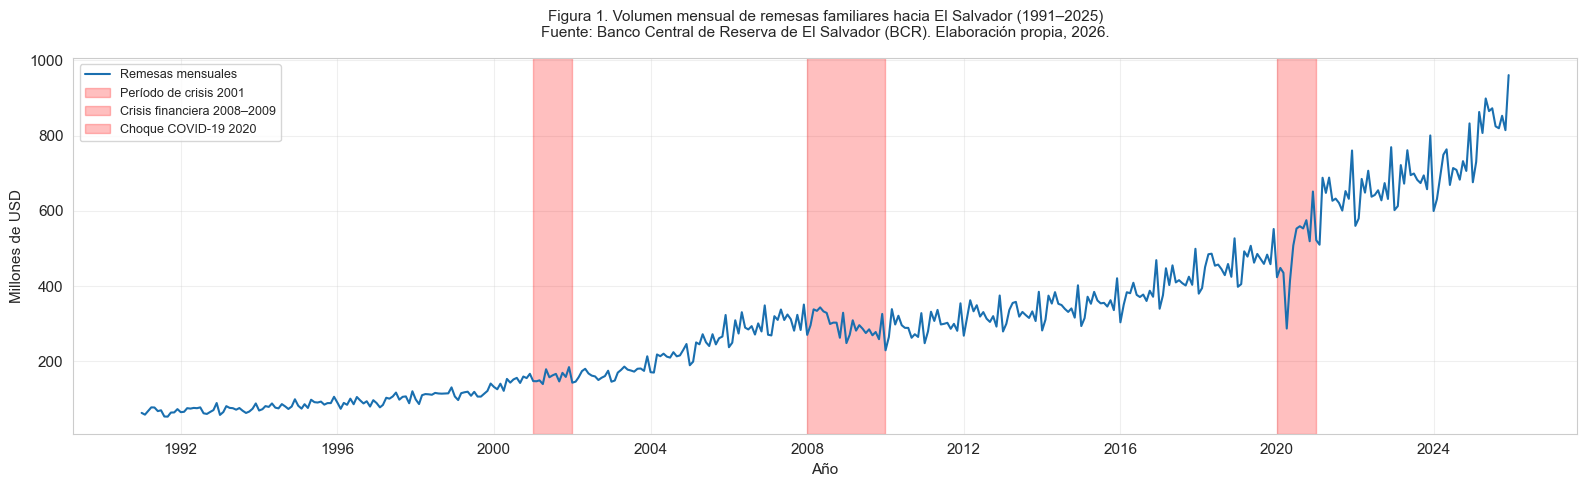

Figura 1 guardada: C:\Users\kmabe\TFM\outputs_eda\figura1_serie_temporal.png


In [8]:
# ============================================================
# 7. EDA — FIGURA 1: SERIE TEMPORAL DE LA VARIABLE OBJETIVO
# ============================================================
# Este gráfico muestra la evolución histórica del volumen mensual
# de remesas entre enero de 1991 y diciembre de 2025.
#
# Se sombrean los períodos definidos mediante la variable
# Dummy_Crisis para facilitar la comparación visual entre
# dichos episodios y el comportamiento temporal de la serie.
# ============================================================

fig, ax = plt.subplots(figsize=(16, 5))
# plt.subplots: crea una figura con sus ejes de coordenadas.
# fig: objeto que representa la figura completa.
# ax: objeto que representa el área donde se dibuja el gráfico.
# figsize=(16, 5): define el tamaño de la figura en pulgadas.

# --- Trazar la línea de remesas ---
ax.plot(
    df.index,                     # Eje X: fechas del índice temporal
    df['Remesas_Millones_USD'],   # Eje Y: volumen mensual de remesas
    color='#1a6faf',              # Color azul
    linewidth=1.5,                # Grosor de la línea
    label='Remesas mensuales'     # Etiqueta para la leyenda
)

# --- Definir períodos de crisis ---
# Los intervalos coinciden con los períodos codificados
# mediante la variable Dummy_Crisis del dataset.
crisis = [
    ('2001-01-01', '2001-12-31', 'Período de crisis 2001'),
    ('2008-01-01', '2009-12-31', 'Crisis financiera 2008–2009'),
    ('2020-01-01', '2020-12-31', 'Choque COVID-19 2020')
]

# --- Sombrear cada período de crisis ---
for inicio, fin, etiqueta in crisis:
    ax.axvspan(
        pd.to_datetime(inicio),
        pd.to_datetime(fin),
        alpha=0.25,
        color='red',
        label=etiqueta
    )

# --- Títulos y etiquetas ---
ax.set_title(
    'Figura 1. Volumen mensual de remesas familiares hacia El Salvador (1991–2025)\n'
    'Fuente: Banco Central de Reserva de El Salvador (BCR). Elaboración propia, 2026.',
    fontsize=11,
    pad=15
)

ax.set_xlabel('Año')
ax.set_ylabel('Millones de USD')
ax.legend(loc='upper left', fontsize=9)

plt.tight_layout()

# --- Exportar figura ---
ruta_figura1 = OUTPUTS_EDA / 'figura1_serie_temporal.png'

plt.savefig(
    ruta_figura1,
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print(
    f"Figura 1 guardada: {ruta_figura1}"
)

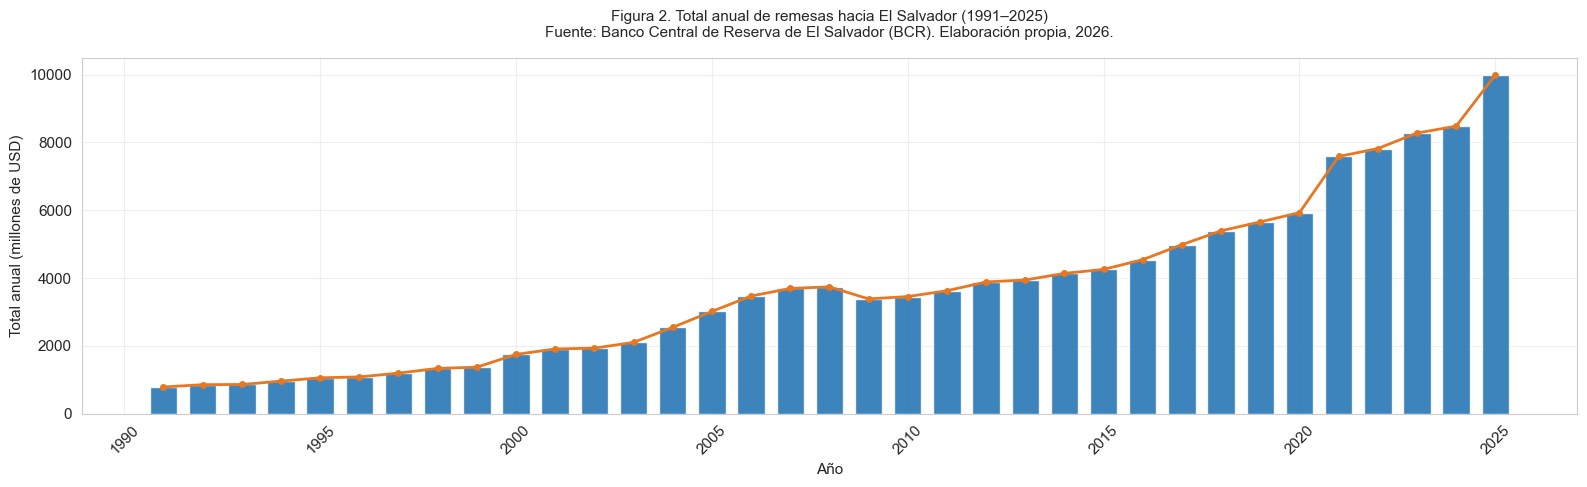

Figura 2 guardada: C:\Users\kmabe\TFM\outputs_eda\figura2_total_anual.png


In [9]:
# ============================================================
# 8. EDA — FIGURA 2: TOTAL ANUAL DE REMESAS (1991–2025)
# ============================================================
# Este gráfico muestra la suma total de remesas registrada
# en cada año del período de análisis.
#
# Complementa la Figura 1 al resumir la serie mensual en
# agregados anuales, facilitando la comparación de su evolución
# a lo largo del tiempo.
# ============================================================

# --- Sumar remesas por año ---
remesas_anuales = (
    df['Remesas_Millones_USD']
    .resample('YE')
    .sum()
)
# resample('YE'): agrupa las observaciones por cierre de año
# (Year End = fin de año).
# .sum(): suma los valores mensuales de cada año para obtener
# el total anual de remesas.
# Nota: 'YE' se utiliza en versiones recientes de pandas;
# en versiones anteriores se empleaba 'Y'.

fig, ax = plt.subplots(figsize=(16, 5))

# --- Barras de total anual ---
ax.bar(
    remesas_anuales.index.year,  # Eje X: años
    remesas_anuales.values,      # Eje Y: total anual en millones de USD
    color='#1a6faf',
    edgecolor='white',           # Borde entre barras para mejorar legibilidad
    alpha=0.85,                  # Nivel de transparencia
    width=0.7                    # Ancho de cada barra
)

# --- Línea de evolución de los totales anuales ---
ax.plot(
    remesas_anuales.index.year,
    remesas_anuales.values,
    color='#e87722',
    linewidth=2,
    marker='o',                  # Punto circular en cada observación anual
    markersize=4
)

# --- Títulos y etiquetas ---
ax.set_title(
    'Figura 2. Total anual de remesas hacia El Salvador (1991–2025)\n'
    'Fuente: Banco Central de Reserva de El Salvador (BCR). '
    'Elaboración propia, 2026.',
    fontsize=11,
    pad=15
)

ax.set_xlabel('Año')
ax.set_ylabel('Total anual (millones de USD)')

plt.xticks(rotation=45)
# xticks(rotation=45): rota las etiquetas del eje X para
# mejorar su legibilidad cuando se muestran numerosos años.

plt.tight_layout()

# --- Exportar figura ---
ruta_figura2 = OUTPUTS_EDA / 'figura2_total_anual.png'

plt.savefig(
    ruta_figura2,
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print(
    f"Figura 2 guardada: {ruta_figura2}"
)

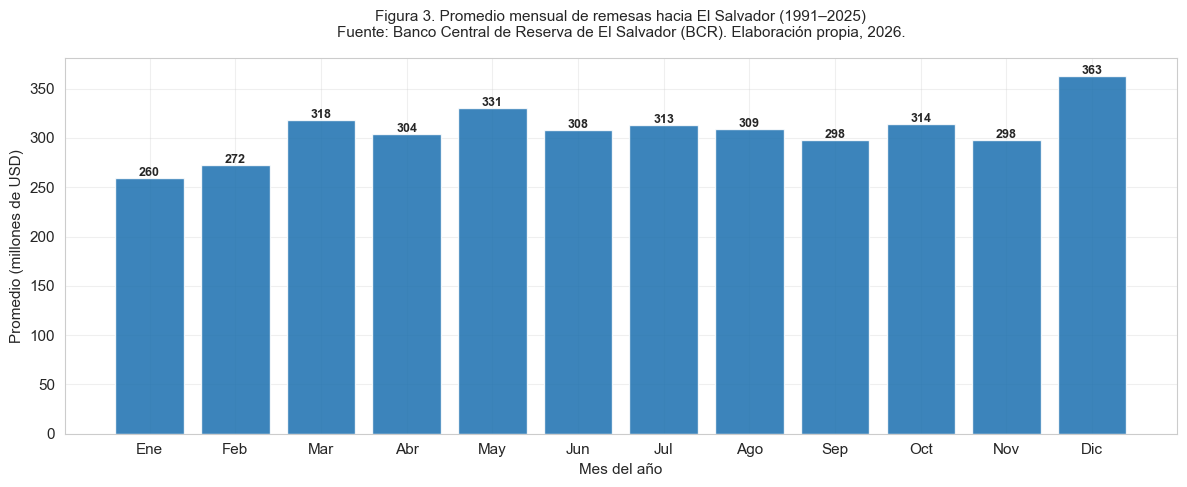

Figura 3 guardada: C:\Users\kmabe\TFM\outputs_eda\figura3_estacionalidad_mensual.png


In [10]:
# ============================================================
# 9. EDA — FIGURA 3: PATRÓN MENSUAL PROMEDIO DE REMESAS
# ============================================================
# Este gráfico examina cómo varía el nivel promedio de remesas
# según el mes del año.
#
# Para cada mes calendario se calcula la media de las
# observaciones correspondientes a todo el período 1991–2025.
# Esta comparación permite explorar posibles patrones mensuales
# recurrentes, que posteriormente se complementan con técnicas
# específicas de análisis estacional.
# ============================================================

# --- Calcular promedio de remesas por mes (1=enero, 12=diciembre) ---
promedio_mensual = (
    df['Remesas_Millones_USD']
    .groupby(df.index.month)
    .mean()
)
# df.index.month: extrae el número del mes (1 al 12) de cada fecha.
# .groupby(): agrupa las observaciones correspondientes al mismo
# mes calendario a lo largo de los distintos años.
# .mean(): calcula el promedio de remesas para cada mes.
# Resultado: una serie con 12 valores, uno por mes del año.

# --- Nombres de los meses en español ---
meses = [
    'Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun',
    'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'
]

fig, ax = plt.subplots(figsize=(12, 5))

# --- Gráfico de barras ---
barras = ax.bar(
    meses,                    # Etiquetas del eje X
    promedio_mensual.values,  # Altura de cada barra = promedio mensual
    color='#1a6faf',
    edgecolor='white',
    alpha=0.85
)

# --- Agregar el valor numérico encima de cada barra ---
for barra in barras:
    # El bucle itera sobre cada barra del gráfico.
    altura = barra.get_height()
    # get_height(): obtiene el valor numérico representado por la barra.

    ax.text(
        barra.get_x() + barra.get_width() / 2,
        # Posición X: centro de la barra.
        altura + 2,
        # Posición Y: ligeramente por encima de la barra.
        f'{altura:.0f}',
        # Texto: valor redondeado al entero más cercano.
        ha='center',
        fontsize=9,
        fontweight='bold'
    )

# --- Títulos y etiquetas ---
ax.set_title(
    'Figura 3. Promedio mensual de remesas hacia El Salvador (1991–2025)\n'
    'Fuente: Banco Central de Reserva de El Salvador (BCR). '
    'Elaboración propia, 2026.',
    fontsize=11,
    pad=15
)

ax.set_xlabel('Mes del año')
ax.set_ylabel('Promedio (millones de USD)')

plt.tight_layout()

# --- Exportar figura ---
ruta_figura3 = OUTPUTS_EDA / 'figura3_estacionalidad_mensual.png'

plt.savefig(
    ruta_figura3,
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print(
    f"Figura 3 guardada: {ruta_figura3}"
)

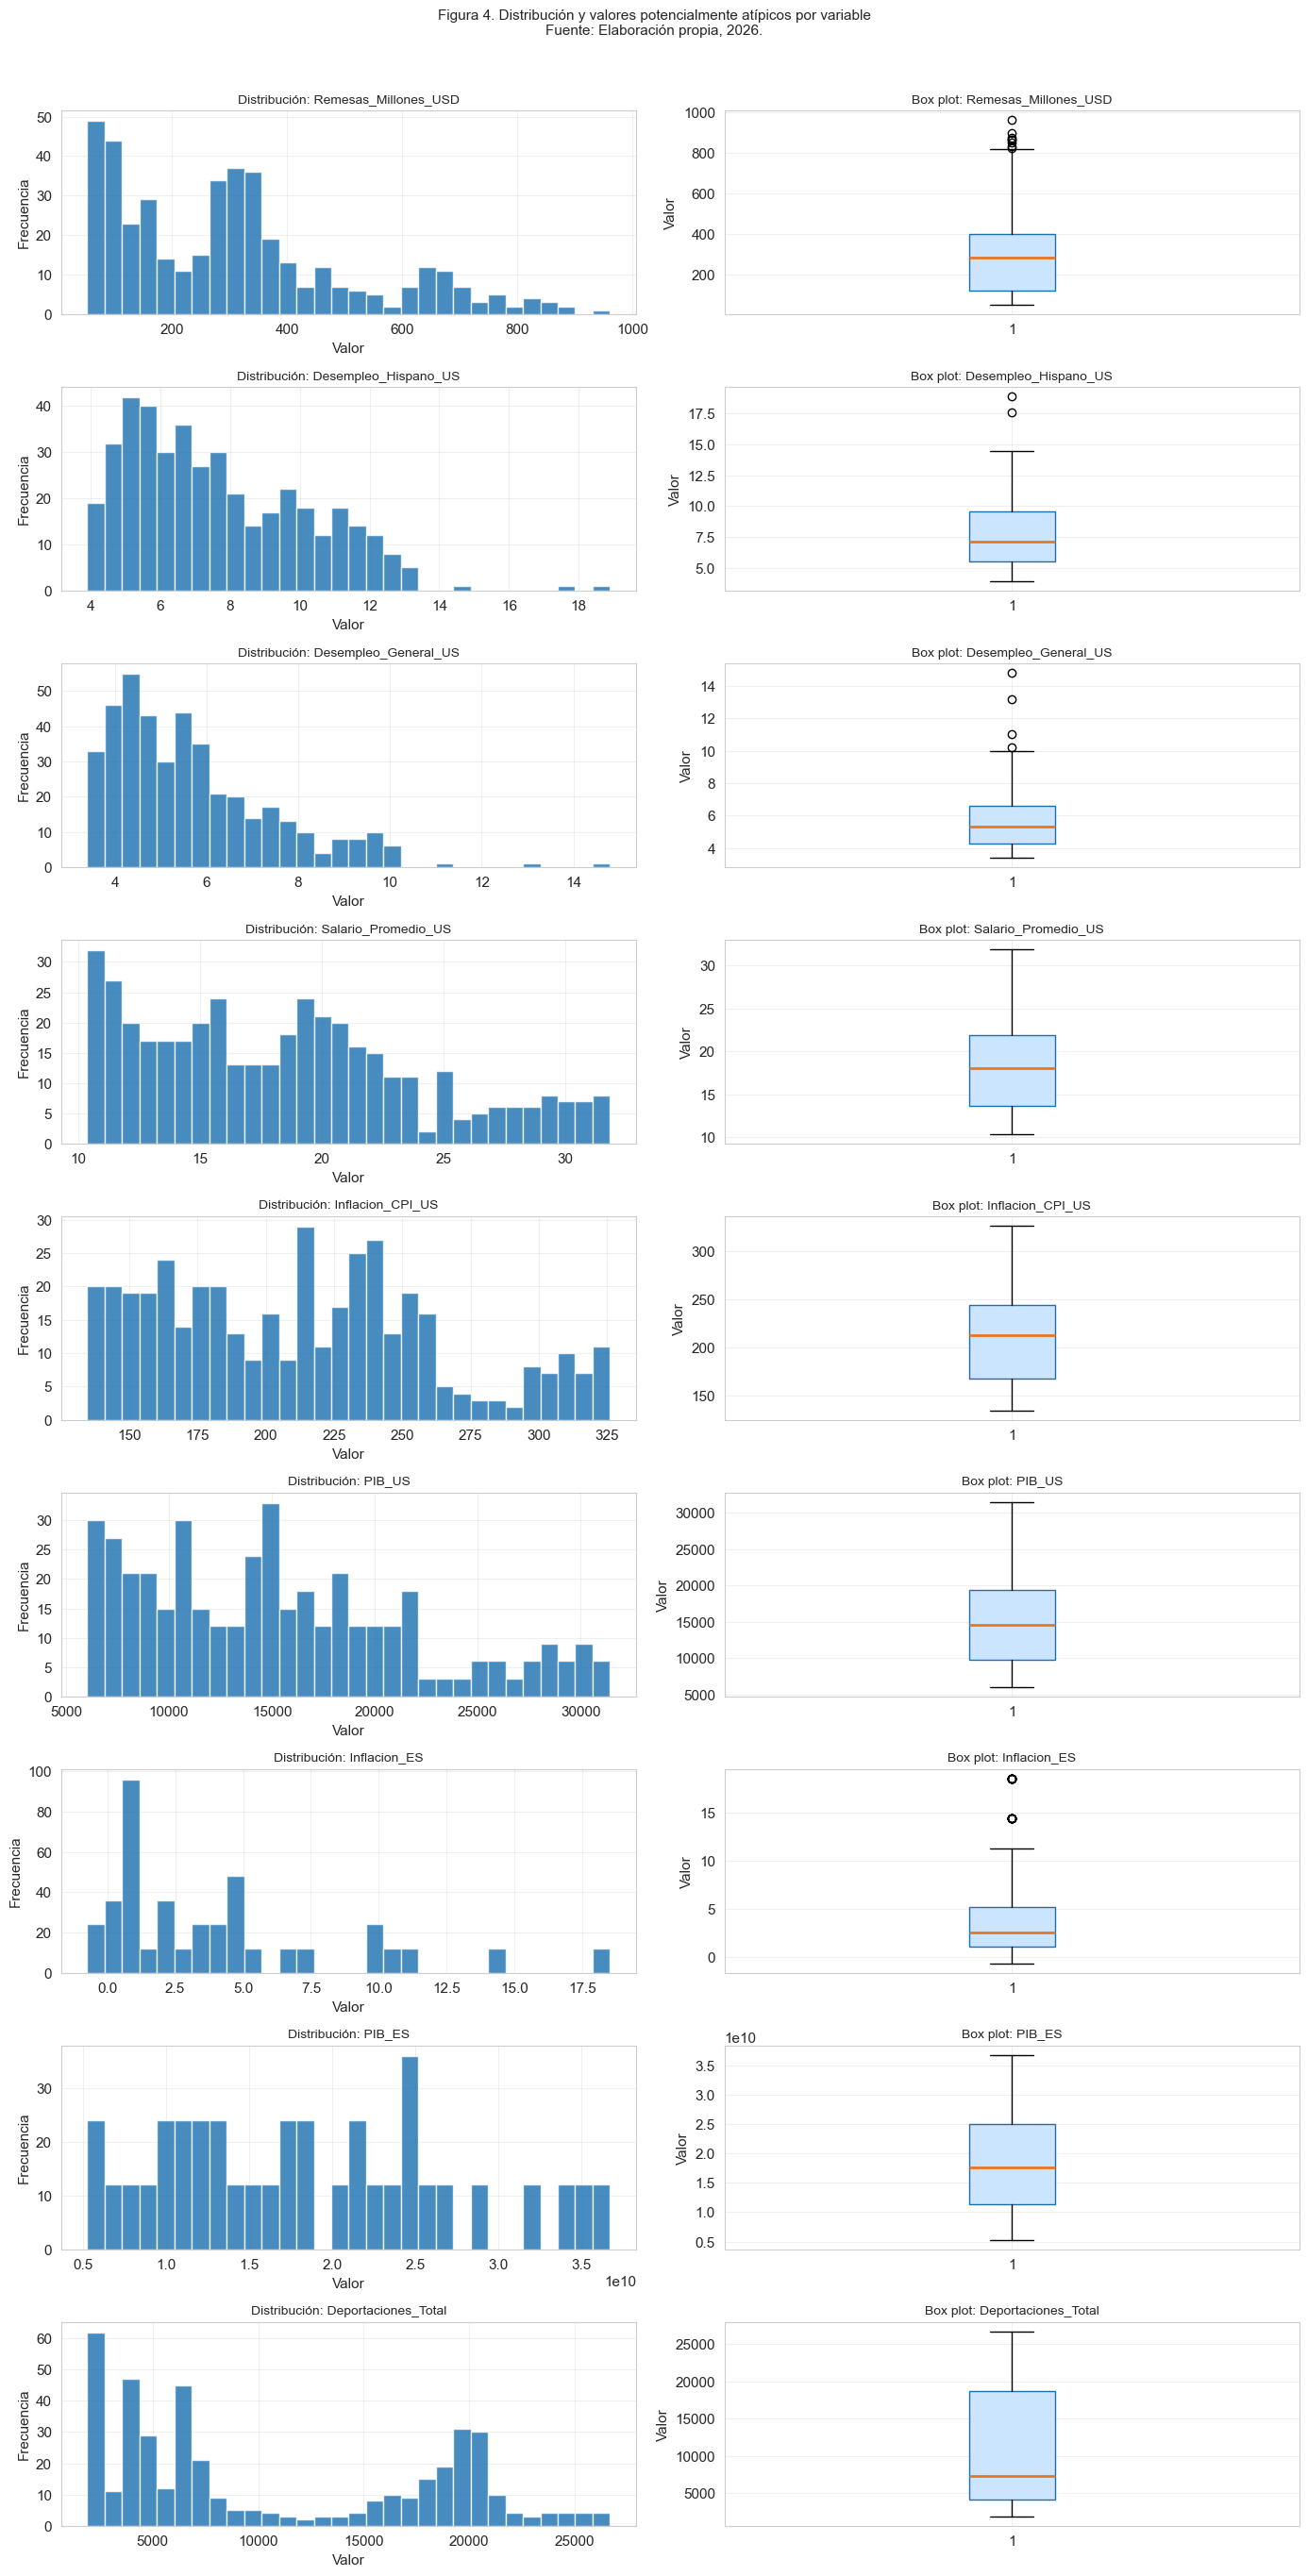

Figura 4 guardada: C:\Users\kmabe\TFM\outputs_eda\figura4_histogramas_boxplots.png


In [11]:
# ============================================================
# 10. EDA — FIGURA 4: DISTRIBUCIÓN Y VALORES POTENCIALMENTE
#     ATÍPICOS POR VARIABLE
# ============================================================
# Se generan dos representaciones gráficas para cada variable
# principal del dataset:
#
# HISTOGRAMA:
# - Muestra la distribución empírica de los valores.
# - Permite explorar simetría, asimetría, concentración y
#   posibles patrones multimodales.
# - Su interpretación es descriptiva y no constituye por sí sola
#   una prueba formal de normalidad.
#
# BOX PLOT (diagrama de caja):
# - La caja representa el rango entre Q1 y Q3.
# - La línea dentro de la caja representa la mediana.
# - Los bigotes se extienden según el criterio estándar basado
#   en 1.5 veces el rango intercuartílico (IQR).
# - Los puntos fuera de los bigotes se consideran valores
#   potencialmente atípicos bajo este criterio gráfico.
#
# Dado que varias variables corresponden a series temporales con
# tendencia o cambios de nivel, estos gráficos se interpretan de
# forma descriptiva y en conjunto con el análisis temporal.
# ============================================================

# Variables principales a analizar (se excluyen rezagos y dummies).
variables_principales = [
    'Remesas_Millones_USD',
    'Desempleo_Hispano_US',
    'Desempleo_General_US',
    'Salario_Promedio_US',
    'Inflacion_CPI_US',
    'PIB_US',
    'Inflacion_ES',
    'PIB_ES',
    'Deportaciones_Total'
]

n = len(variables_principales)
# n: número de variables a representar y, por tanto,
# número de filas de subgráficos.

# --- Crear cuadrícula: n filas, 2 columnas ---
fig, axes = plt.subplots(
    n,
    2,
    figsize=(14, n * 3)
)
# n filas: una por variable.
# 2 columnas: histograma y box plot.
# figsize=(14, n*3): altura proporcional al número de variables.

# --- Generar histograma y box plot para cada variable ---
for i, var in enumerate(variables_principales):
    # enumerate(): devuelve el índice i y el nombre de la variable
    # en cada iteración del bucle.

    # ---- HISTOGRAMA (columna izquierda) ----
    axes[i, 0].hist(
        df[var].dropna(),
        # dropna(): excluye valores faltantes antes de graficar.
        bins=30,
        # bins=30: divide el rango de valores en 30 intervalos.
        color='#1a6faf',
        edgecolor='white',
        alpha=0.8
    )

    axes[i, 0].set_title(
        f'Distribución: {var}',
        fontsize=10
    )
    axes[i, 0].set_xlabel('Valor')
    axes[i, 0].set_ylabel('Frecuencia')
    # Frecuencia: número de observaciones en cada intervalo.

    # ---- BOX PLOT (columna derecha) ----
    axes[i, 1].boxplot(
        df[var].dropna(),
        vert=True,
        # Orientación vertical.
        patch_artist=True,
        # Permite colorear el interior de la caja.
        boxprops=dict(
            facecolor='#cce5ff',
            color='#1a6faf'
        ),
        medianprops=dict(
            color='#e87722',
            linewidth=2
        )
    )

    axes[i, 1].set_title(
        f'Box plot: {var}',
        fontsize=10
    )
    axes[i, 1].set_ylabel('Valor')

# --- Título general ---
plt.suptitle(
    'Figura 4. Distribución y valores potencialmente atípicos por variable\n'
    'Fuente: Elaboración propia, 2026.',
    fontsize=11,
    y=1.01
)
# y=1.01: coloca el título ligeramente por encima de los gráficos.

plt.tight_layout()

ruta_figura4 = OUTPUTS_EDA / 'figura4_histogramas_boxplots.png'

plt.savefig(
    ruta_figura4,
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print(
    f"Figura 4 guardada: {ruta_figura4}"
)

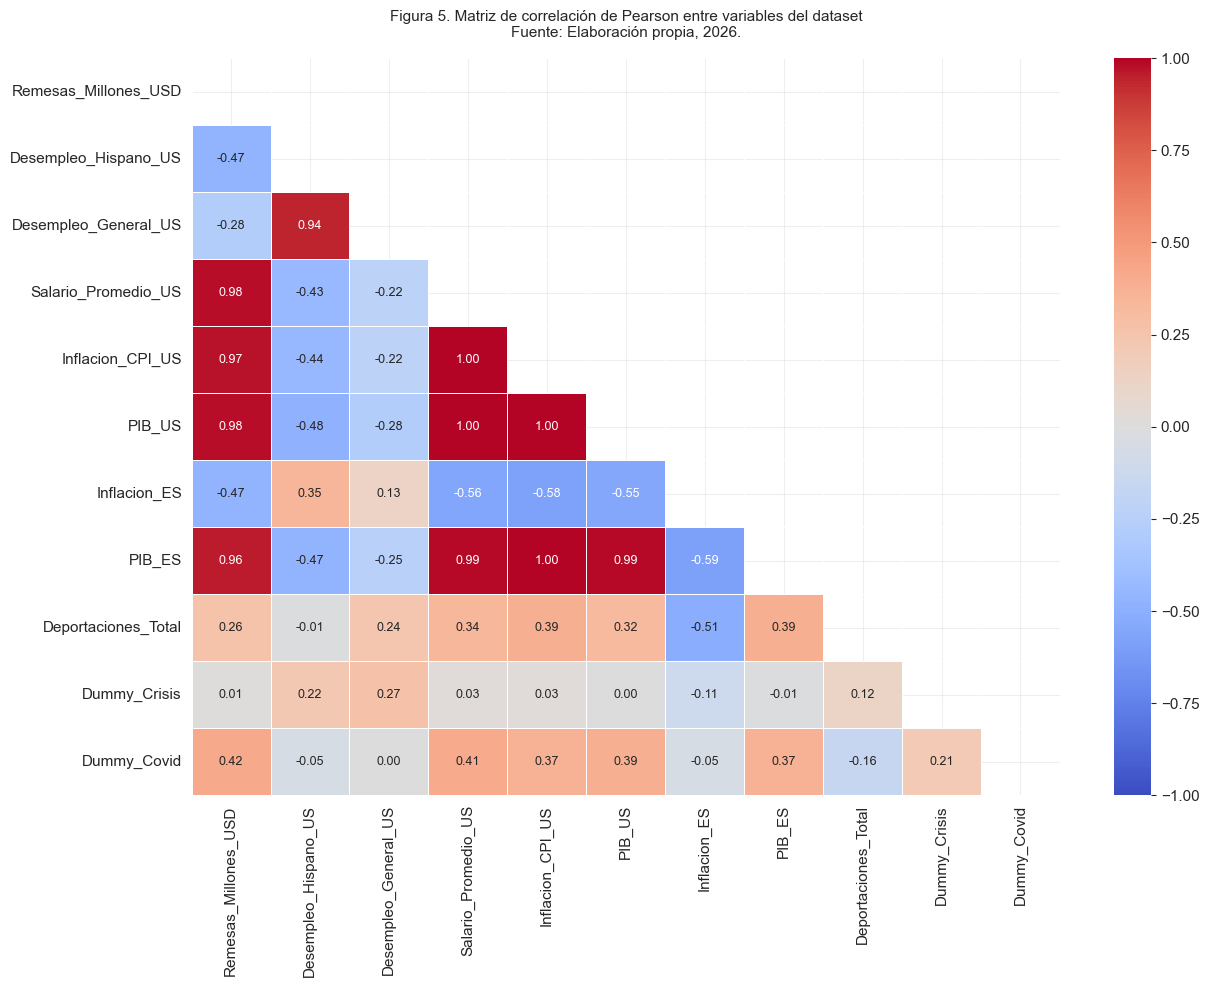


=== CORRELACIÓN DE CADA VARIABLE CON REMESAS ===
Valores cercanos a 1 o -1 indican una asociación lineal más intensa con las remesas.
Valores cercanos a 0 indican una asociación lineal débil o inexistente.



,Correlación con Remesas_Millones_USD
Remesas_Millones_USD,1.00
Salario_Promedio_US,0.98
PIB_US,0.98
Inflacion_CPI_US,0.97
PIB_ES,0.96
Dummy_Covid,0.42
Deportaciones_Total,0.26
Dummy_Crisis,0.01
Desempleo_General_US,-0.28
Desempleo_Hispano_US,-0.47


Figura 5 guardada: C:\Users\kmabe\TFM\outputs_eda\figura5_heatmap_correlacion.png
Tabla exportada: C:\Users\kmabe\TFM\outputs_eda\tabla_correlaciones_remesas.csv


In [12]:
# ============================================================
# 11. EDA — FIGURA 5: MATRIZ DE CORRELACIÓN DE PEARSON
# ============================================================
# El coeficiente de correlación de Pearson mide la intensidad
# y dirección de la asociación lineal entre dos variables.
# Su valor se encuentra entre -1 y 1:
#   +1: asociación lineal positiva perfecta.
#   -1: asociación lineal negativa perfecta.
#    0: ausencia de asociación lineal.
#
# La interpretación debe realizarse con cautela:
# - Correlación no implica causalidad.
# - Varias variables del dataset presentan tendencia temporal,
#   por lo que correlaciones elevadas pueden reflejar parcialmente
#   movimientos comunes a lo largo del tiempo.
# - Un coeficiente cercano a cero no descarta relaciones no lineales.
#
# Se muestra únicamente el triángulo inferior porque la matriz
# es simétrica: la correlación de A con B coincide con la de B con A.
# ============================================================

# --- Seleccionar variables para la correlación ---
vars_correlacion = [
    'Remesas_Millones_USD',
    'Desempleo_Hispano_US',
    'Desempleo_General_US',
    'Salario_Promedio_US',
    'Inflacion_CPI_US',
    'PIB_US',
    'Inflacion_ES',
    'PIB_ES',
    'Deportaciones_Total',
    'Dummy_Crisis',
    'Dummy_Covid'
]
# Se excluyen las variables rezagadas para evitar redundancia
# visual en la matriz. Su estructura temporal se analiza
# posteriormente mediante herramientas específicas como ACF y PACF.

# --- Calcular la matriz de correlación ---
correlacion = (
    df[vars_correlacion]
    .corr(method='pearson')
    .round(2)
)
# .corr(): calcula la correlación entre todos los pares de columnas.
# method='pearson': utiliza el coeficiente de correlación de Pearson.
# .round(2): redondea los coeficientes a 2 decimales.

# --- Crear máscara para el triángulo superior ---
mask = np.triu(
    np.ones_like(correlacion, dtype=bool)
)
# np.ones_like(): crea una matriz con la misma forma que correlacion.
# np.triu(): selecciona el triángulo superior, incluida la diagonal.
# La máscara permite ocultar las celdas redundantes del heatmap.

fig, ax = plt.subplots(figsize=(13, 10))

# --- Generar el heatmap ---
sns.heatmap(
    correlacion,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    annot_kws={'size': 9},
    ax=ax
)
# annot=True: muestra el coeficiente en cada celda visible.
# center=0: centra la escala cromática en ausencia de correlación.
# vmin=-1 y vmax=1: fijan el rango teórico del coeficiente.

ax.set_title(
    'Figura 5. Matriz de correlación de Pearson entre variables del dataset\n'
    'Fuente: Elaboración propia, 2026.',
    fontsize=11,
    pad=15
)

plt.tight_layout()

# --- Exportar Figura 5 ---
ruta_figura5 = OUTPUTS_EDA / 'figura5_heatmap_correlacion.png'

plt.savefig(
    ruta_figura5,
    dpi=150,
    bbox_inches='tight'
)

plt.show()

# --- Mostrar correlaciones con la variable objetivo ordenadas ---
print("\n=== CORRELACIÓN DE CADA VARIABLE CON REMESAS ===")
print(
    "Valores cercanos a 1 o -1 indican una asociación lineal "
    "más intensa con las remesas."
)
print(
    "Valores cercanos a 0 indican una asociación lineal débil "
    "o inexistente.\n"
)

correlacion_remesas = (
    correlacion['Remesas_Millones_USD']
    .sort_values(ascending=False)
)
# sort_values(ascending=False): ordena los coeficientes
# desde el valor más alto hasta el más bajo.

display(
    correlacion_remesas.to_frame(
        name='Correlación con Remesas_Millones_USD'
    )
)
# .to_frame(): convierte la serie en DataFrame para facilitar
# su lectura y presentación.

# --- Exportar tabla de correlaciones ---
ruta_tabla_correlaciones = (
    OUTPUTS_EDA / 'tabla_correlaciones_remesas.csv'
)

correlacion_remesas.to_csv(
    ruta_tabla_correlaciones
)

print(
    f"Figura 5 guardada: {ruta_figura5}"
)
print(
    f"Tabla exportada: {ruta_tabla_correlaciones}"
)

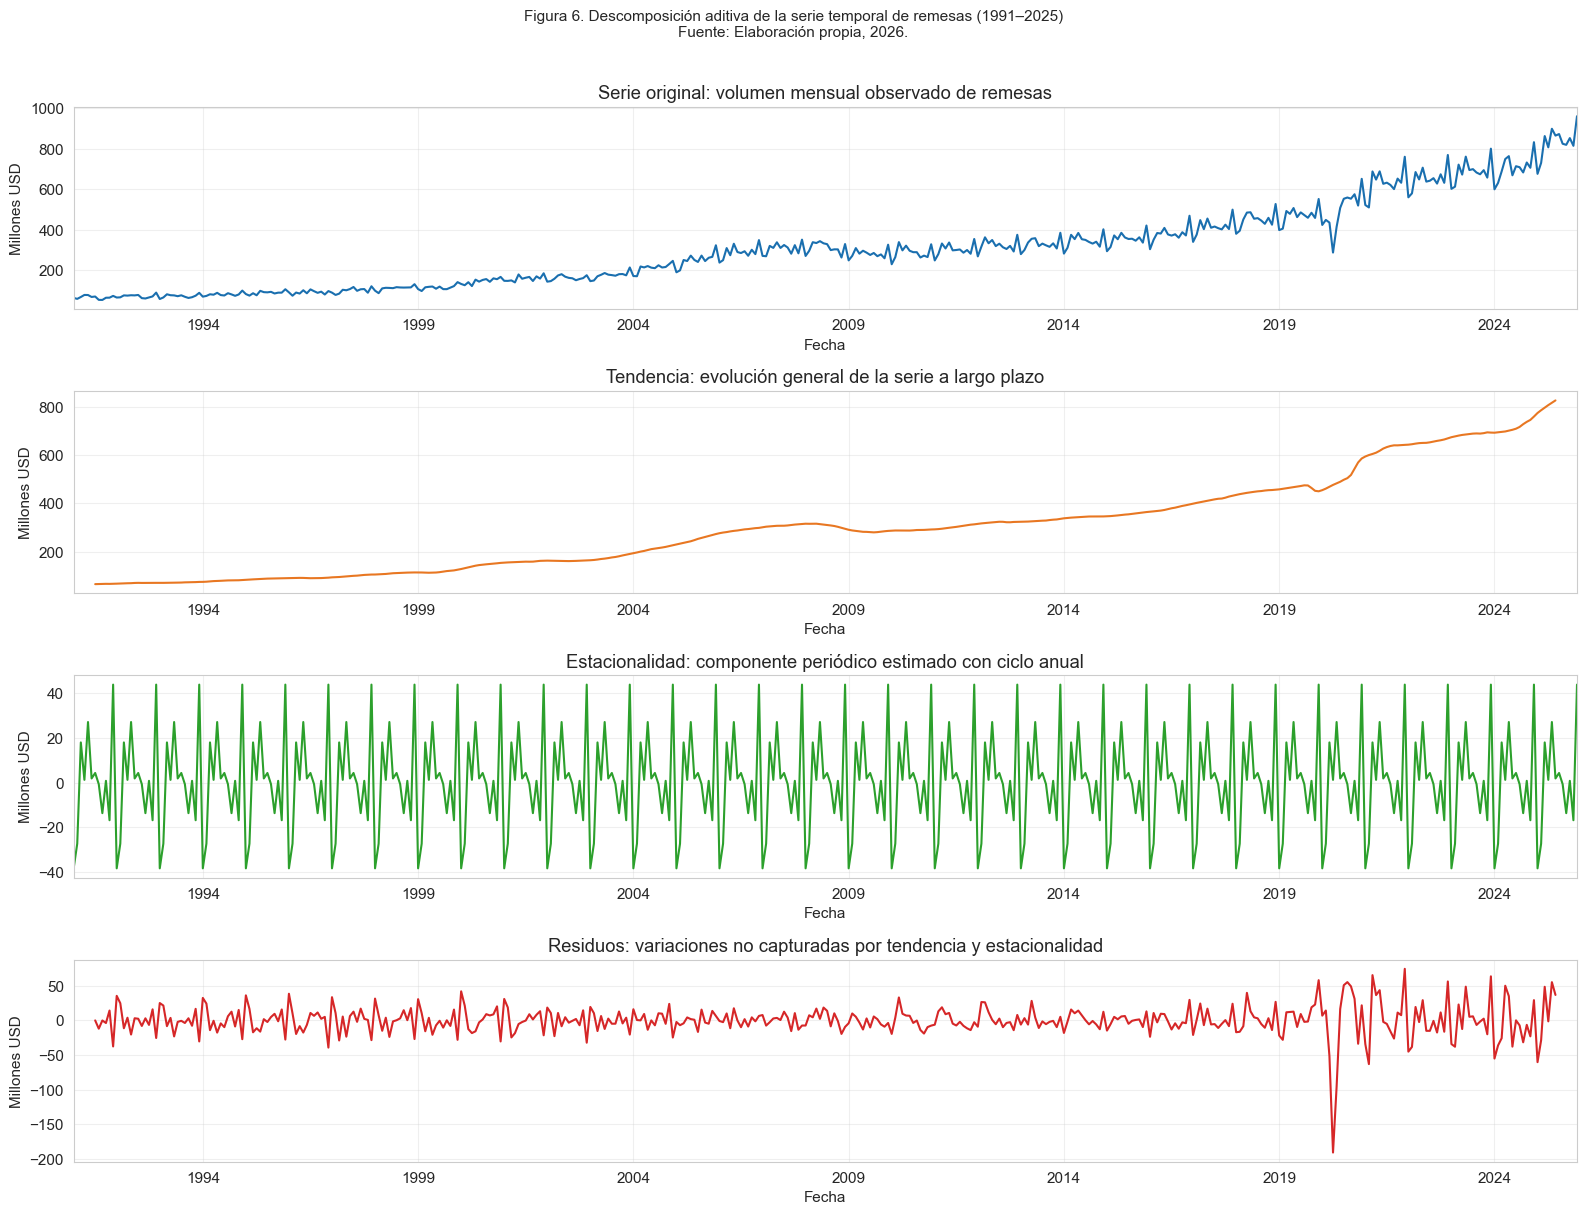

Figura 6 guardada: C:\Users\kmabe\TFM\outputs_eda\figura6_descomposicion_serie.png


In [13]:
# ============================================================
# 12. EDA — FIGURA 6: DESCOMPOSICIÓN ADITIVA DE LA SERIE TEMPORAL
# ============================================================
# La descomposición permite separar la serie temporal en
# componentes que facilitan el análisis de su estructura:
#
# TENDENCIA:
# - Representa la evolución general de la serie a largo plazo.
#
# ESTACIONALIDAD:
# - Representa patrones sistemáticos que se repiten con una
#   periodicidad definida.
# - Se establece period=12 debido a la frecuencia mensual de
#   los datos y al interés en examinar un ciclo anual.
#
# RESIDUOS:
# - Representan las variaciones que permanecen después de
#   separar los componentes de tendencia y estacionalidad.
# - Valores residuales elevados, positivos o negativos, pueden
#   señalar episodios no capturados por los otros componentes,
#   sin implicar por sí solos una causa específica.
#
# Se utiliza una descomposición aditiva:
#
#   Serie = Tendencia + Estacionalidad + Residuos
#
# Este enfoque supone que el efecto estacional se expresa en
# magnitudes aproximadamente aditivas respecto al nivel de la serie.
# La descomposición se utiliza con fines exploratorios.
# ============================================================

# --- Aplicar la descomposición ---
descomposicion = seasonal_decompose(
    df['Remesas_Millones_USD'].dropna(),
    # Serie sin valores faltantes.
    model='additive',
    # Modelo aditivo: los componentes se combinan mediante suma.
    period=12
    # Período estacional de 12 observaciones, equivalente a un año
    # para una serie de frecuencia mensual.
)

# --- Crear figura con 4 subgráficos apilados ---
fig, axes = plt.subplots(
    4,
    1,
    figsize=(16, 12)
)
# 4 filas: serie observada, tendencia, estacionalidad y residuos.

# --- Gráfico 1: Serie original ---
descomposicion.observed.plot(
    ax=axes[0],
    color='#1a6faf'
)
axes[0].set_title(
    'Serie original: volumen mensual observado de remesas'
)
axes[0].set_ylabel('Millones USD')

# --- Gráfico 2: Tendencia ---
descomposicion.trend.plot(
    ax=axes[1],
    color='#e87722'
)
axes[1].set_title(
    'Tendencia: evolución general de la serie a largo plazo'
)
axes[1].set_ylabel('Millones USD')
# Los primeros y últimos meses pueden aparecer sin estimación
# debido al cálculo de la tendencia mediante medias móviles
# centradas, que requieren observaciones a ambos lados.

# --- Gráfico 3: Estacionalidad ---
descomposicion.seasonal.plot(
    ax=axes[2],
    color='#2ca02c'
)
axes[2].set_title(
    'Estacionalidad: componente periódico estimado con ciclo anual'
)
axes[2].set_ylabel('Millones USD')
# Valores positivos indican meses en los que el componente
# estacional estimado contribuye por encima del nivel esperado;
# valores negativos indican una contribución por debajo.

# --- Gráfico 4: Residuos ---
descomposicion.resid.plot(
    ax=axes[3],
    color='#d62728'
)
axes[3].set_title(
    'Residuos: variaciones no capturadas por tendencia y estacionalidad'
)
axes[3].set_ylabel('Millones USD')
# Valores residuales elevados, positivos o negativos, reflejan
# desviaciones no explicadas por los componentes estimados.
# Su interpretación causal requiere evidencia adicional.

fig.suptitle(
    'Figura 6. Descomposición aditiva de la serie temporal de remesas (1991–2025)\n'
    'Fuente: Elaboración propia, 2026.',
    fontsize=11,
    y=1.01
)

plt.tight_layout()

# --- Exportar Figura 6 ---
ruta_figura6 = OUTPUTS_EDA / 'figura6_descomposicion_serie.png'

plt.savefig(
    ruta_figura6,
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print(
    f"Figura 6 guardada: {ruta_figura6}"
)

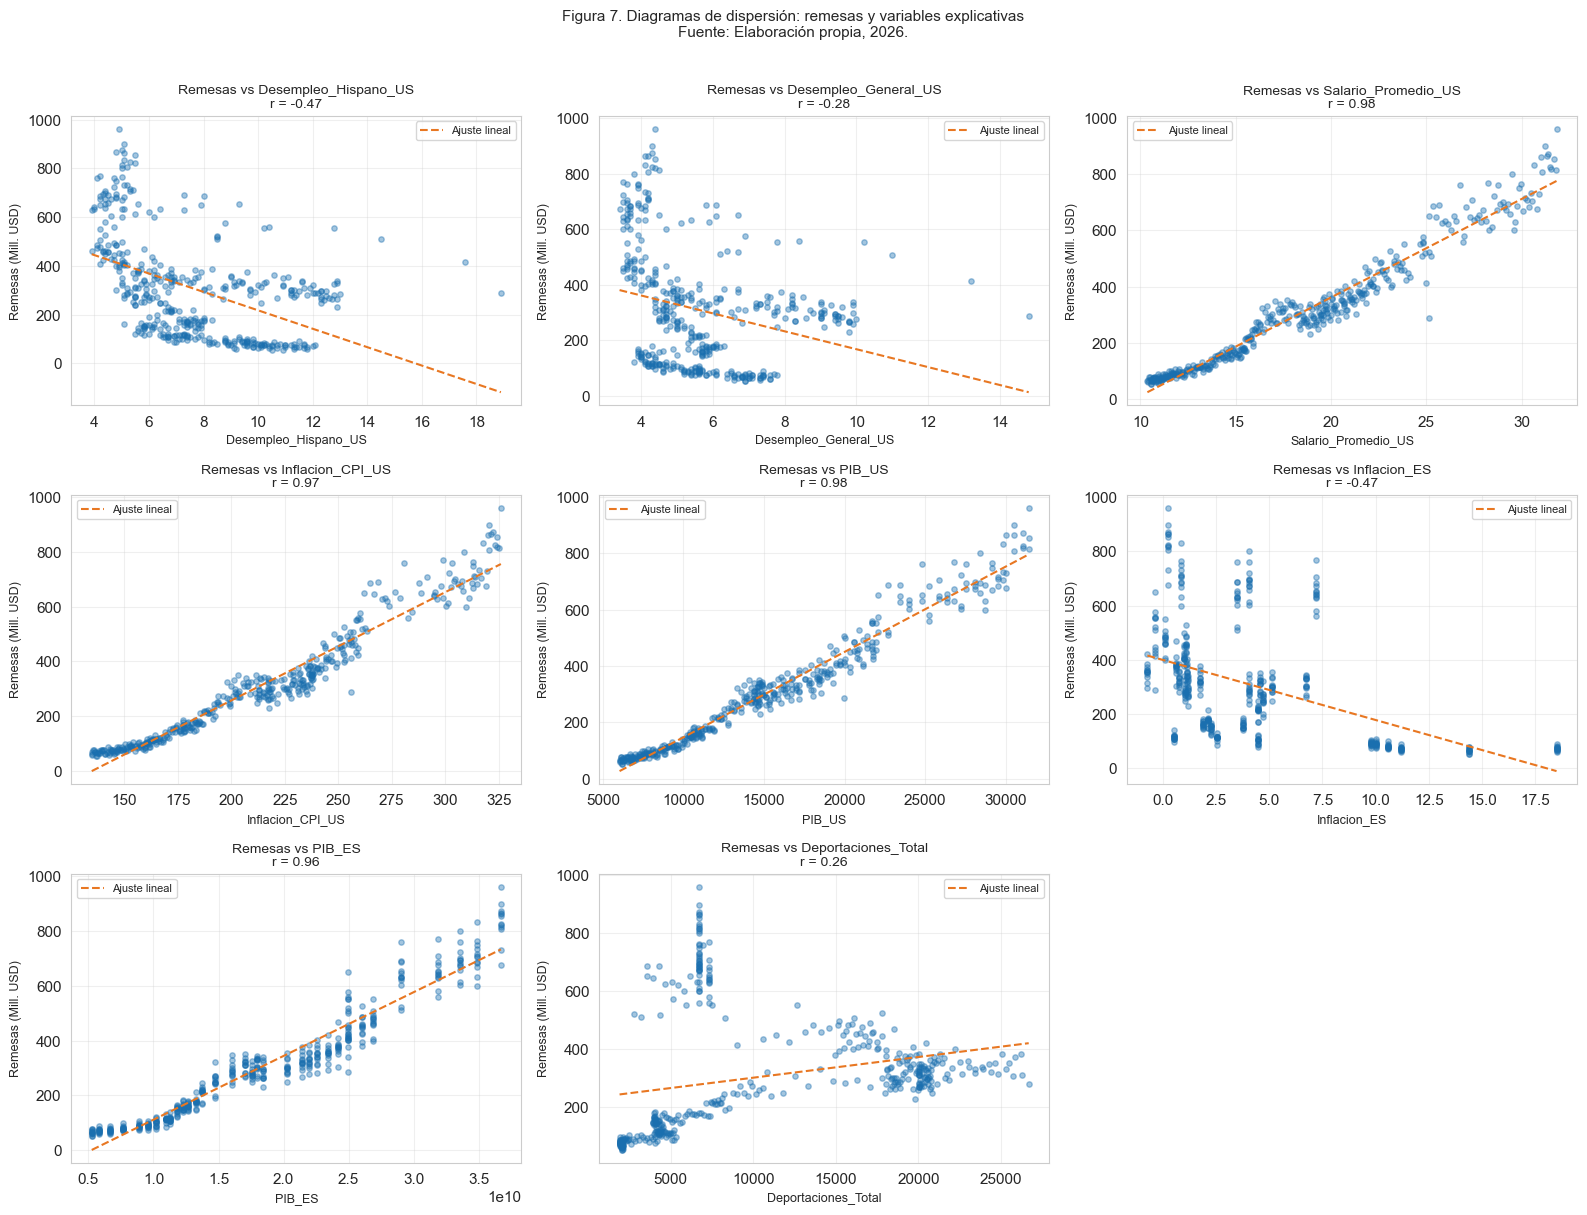

Figura 7 guardada: C:\Users\kmabe\TFM\outputs_eda\figura7_dispersion.png


In [14]:
# ============================================================
# 13. EDA — FIGURA 7: DIAGRAMAS DE DISPERSIÓN
# ============================================================
# Los diagramas de dispersión permiten explorar la asociación
# bivariada entre la variable objetivo (remesas) y cada variable
# explicativa considerada.
# Cada punto representa una observación mensual del período.
#
# La línea punteada naranja corresponde a una recta de ajuste
# lineal estimada mediante mínimos cuadrados con np.polyfit.
#
# Interpretación:
# - Puntos próximos a la recta sugieren una asociación lineal
#   más marcada.
# - Una mayor dispersión alrededor de la recta sugiere una
#   asociación lineal más débil.
# - Una pendiente positiva indica asociación lineal directa.
# - Una pendiente negativa indica asociación lineal inversa.
#
# El valor r mostrado en cada título corresponde al coeficiente
# de correlación de Pearson entre la variable representada
# y la variable objetivo.
#
# Estas relaciones se interpretan con cautela: correlación y
# ajuste lineal no implican causalidad. Además, la presencia de
# tendencias temporales comunes puede contribuir a asociaciones
# elevadas entre algunas variables.
# ============================================================

# --- Variables explicativas a graficar ---
predictoras = [
    'Desempleo_Hispano_US',
    'Desempleo_General_US',
    'Salario_Promedio_US',
    'Inflacion_CPI_US',
    'PIB_US',
    'Inflacion_ES',
    'PIB_ES',
    'Deportaciones_Total'
]

n = len(predictoras)
cols = 3
# Número de columnas en la cuadrícula de gráficos.

filas = (n + cols - 1) // cols
# Calcula el número de filas necesarias mediante división
# entera redondeada hacia arriba.

fig, axes = plt.subplots(
    filas,
    cols,
    figsize=(16, filas * 4)
)

axes = axes.flatten()
# flatten(): convierte la matriz bidimensional de ejes en un
# arreglo unidimensional para acceder a cada gráfico mediante axes[i].

# --- Generar un diagrama por cada variable explicativa ---
for i, var in enumerate(predictoras):

    # --- Máscara para excluir NaN en ambas variables ---
    mascara = (
        df[var].notna()
        & df['Remesas_Millones_USD'].notna()
    )
    # notna(): identifica observaciones no faltantes.
    # &: exige que ambas variables tengan valores disponibles.
    # Esta selección es necesaria porque np.polyfit no acepta NaN.

    # --- Diagrama de dispersión ---
    axes[i].scatter(
        df[var][mascara],
        # Eje X: variable explicativa.
        df['Remesas_Millones_USD'][mascara],
        # Eje Y: variable objetivo.
        alpha=0.4,
        # Transparencia para visualizar puntos superpuestos.
        color='#1a6faf',
        s=15
        # Tamaño de cada punto.
    )

    # --- Calcular recta de ajuste lineal ---
    z = np.polyfit(
        df[var][mascara],
        df['Remesas_Millones_USD'][mascara],
        1
    )
    # np.polyfit(..., 1): estima los coeficientes de una recta
    # mediante mínimos cuadrados.
    # El resultado contiene pendiente e intercepto.

    p = np.poly1d(z)
    # np.poly1d(): convierte los coeficientes estimados en una
    # función evaluable para representar la recta.

    x_sorted = np.sort(
        df[var][mascara]
    )
    # Ordena los valores X de menor a mayor para trazar
    # correctamente la recta de ajuste.

    axes[i].plot(
        x_sorted,
        p(x_sorted),
        color='#e87722',
        linewidth=1.5,
        linestyle='--',
        label='Ajuste lineal'
    )

    # --- Calcular y mostrar correlación en el título ---
    corr_val = (
        df[var][mascara]
        .corr(
            df['Remesas_Millones_USD'][mascara]
        )
    )
    # .corr(): calcula el coeficiente de correlación de Pearson
    # entre la variable representada y las remesas.

    axes[i].set_xlabel(
        var,
        fontsize=9
    )

    axes[i].set_ylabel(
        'Remesas (Mill. USD)',
        fontsize=9
    )

    axes[i].set_title(
        f'Remesas vs {var}\nr = {corr_val:.2f}',
        fontsize=10
    )

    axes[i].legend(fontsize=8)

# --- Ocultar ejes sobrantes si no se completa la cuadrícula ---
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
    # set_visible(False): oculta los subgráficos vacíos.

fig.suptitle(
    'Figura 7. Diagramas de dispersión: remesas y variables explicativas\n'
    'Fuente: Elaboración propia, 2026.',
    fontsize=11,
    y=1.01
)

plt.tight_layout()

# --- Exportar Figura 7 ---
ruta_figura7 = OUTPUTS_EDA / 'figura7_dispersion.png'

plt.savefig(
    ruta_figura7,
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print(
    f"Figura 7 guardada: {ruta_figura7}"
)

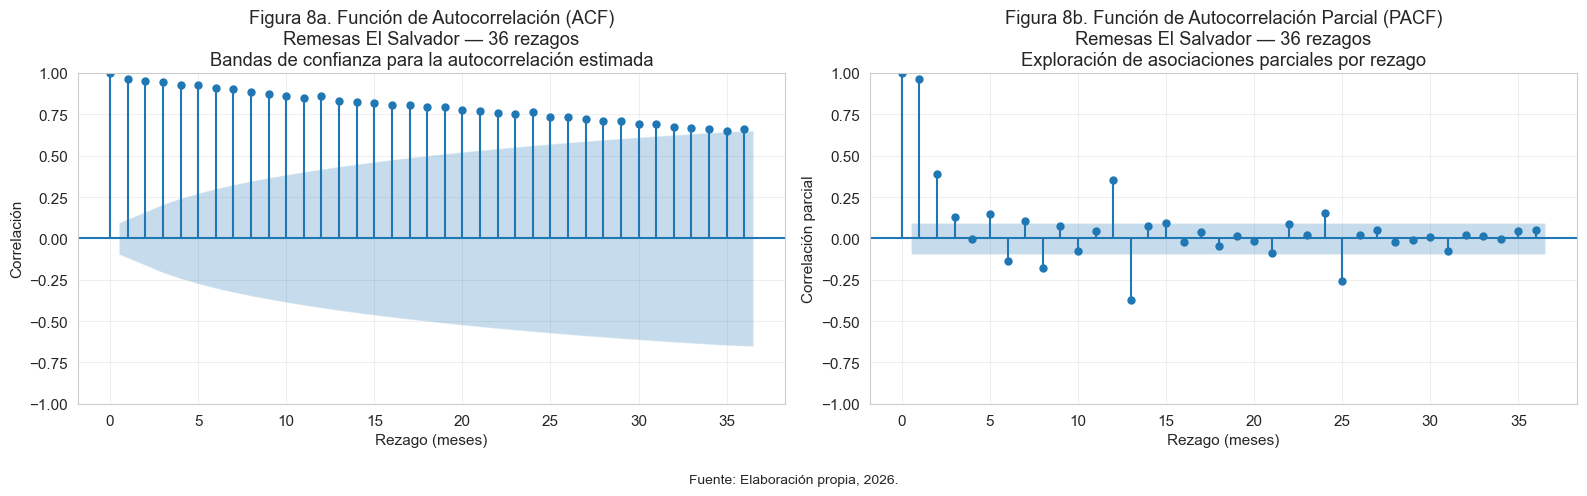

Figura 8 guardada: C:\Users\kmabe\TFM\outputs_eda\figura8_acf_pacf.png


In [15]:
# ============================================================
# 14. EDA — FIGURA 8: AUTOCORRELACIÓN (ACF) Y
#     AUTOCORRELACIÓN PARCIAL (PACF)
# ============================================================
# Estos gráficos permiten explorar la dependencia temporal de
# la serie de remesas y aportan evidencia descriptiva para
# examinar la posible utilidad de variables rezagadas.
#
# ACF - Función de Autocorrelación:
# - Mide la asociación lineal entre la serie y sus propios
#   valores pasados para distintos rezagos.
# - Valores elevados en determinados rezagos indican persistencia
#   temporal o patrones de dependencia serial.
#
# PACF - Función de Autocorrelación Parcial:
# - Mide la asociación entre la serie y un rezago específico,
#   controlando el efecto lineal de los rezagos intermedios.
# - Permite explorar qué rezagos presentan una relación parcial
#   destacada con la serie.
#
# Las bandas de confianza permiten identificar coeficientes que
# se apartan de cero bajo los supuestos del procedimiento.
# Sin embargo, superar estas bandas no implica causalidad ni
# garantiza por sí solo utilidad predictiva en un modelo.
#
# Dado que la serie presenta una marcada evolución temporal,
# la ACF y la PACF en niveles deben interpretarse junto con el
# análisis de estacionariedad desarrollado posteriormente.
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 5)
)
# 1 fila y 2 columnas:
# ACF a la izquierda y PACF a la derecha.

# --- Gráfico ACF ---
plot_acf(
    df['Remesas_Millones_USD'].dropna(),
    # Serie sin valores faltantes.
    lags=36,
    # Se examinan hasta 36 rezagos mensuales, equivalentes
    # a tres años de historia.
    ax=axes[0]
)

axes[0].set_title(
    'Figura 8a. Función de Autocorrelación (ACF)\n'
    'Remesas El Salvador — 36 rezagos\n'
    'Bandas de confianza para la autocorrelación estimada'
)

axes[0].set_xlabel('Rezago (meses)')
axes[0].set_ylabel('Correlación')

# --- Gráfico PACF ---
plot_pacf(
    df['Remesas_Millones_USD'].dropna(),
    # Serie sin valores faltantes.
    lags=36,
    # Se examinan hasta 36 rezagos mensuales.
    ax=axes[1]
)

axes[1].set_title(
    'Figura 8b. Función de Autocorrelación Parcial (PACF)\n'
    'Remesas El Salvador — 36 rezagos\n'
    'Exploración de asociaciones parciales por rezago'
)

axes[1].set_xlabel('Rezago (meses)')
axes[1].set_ylabel('Correlación parcial')

# --- Fuente general de la figura ---
plt.suptitle(
    'Fuente: Elaboración propia, 2026.',
    fontsize=10,
    y=-0.02
)

plt.tight_layout()

# --- Exportar Figura 8 ---
ruta_figura8 = OUTPUTS_EDA / 'figura8_acf_pacf.png'

plt.savefig(
    ruta_figura8,
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print(
    f"Figura 8 guardada: {ruta_figura8}"
)

In [16]:
# ============================================================
# 15. EDA — PRUEBA DE ESTACIONARIEDAD (ADF)
# ============================================================
# La estacionariedad es una propiedad relevante en el análisis
# de series temporales. De forma general, una serie estacionaria
# mantiene propiedades estadísticas estables a lo largo del tiempo.
#
# La prueba de Dickey-Fuller Aumentada (ADF) permite evaluar
# evidencia sobre la presencia de una raíz unitaria en la serie.
#
# Hipótesis de la prueba:
# H0 (hipótesis nula)       : la serie presenta una raíz unitaria.
# H1 (hipótesis alternativa): la serie no presenta una raíz unitaria
#                             bajo la especificación evaluada.
#
# Regla de decisión utilizada:
# p-valor <= 0.05 → se rechaza H0.
# p-valor >  0.05 → no se rechaza H0.
#
# El rechazo de H0 aporta evidencia a favor de estacionariedad
# bajo la especificación de la prueba. No rechazar H0 indica que
# no existe evidencia suficiente para descartar una raíz unitaria.
#
# La interpretación debe realizarse junto con la inspección gráfica
# y otras características de la serie. En caso de no estacionariedad,
# pueden evaluarse transformaciones o diferenciación según el
# objetivo analítico y el modelo utilizado.
# ============================================================


def prueba_adf(serie, nombre_variable):
    """
    Aplica la prueba ADF a una serie y muestra el resultado.

    Parámetros:
    - serie: serie de datos a analizar.
    - nombre_variable: nombre descriptivo de la variable.
    """

    # --- Aplicar la prueba ADF ---
    resultado = adfuller(
        serie.dropna()
    )
    # dropna(): excluye valores faltantes antes de aplicar la prueba.
    #
    # adfuller devuelve, entre otros elementos:
    # [0]: estadístico ADF.
    # [1]: p-valor.
    # [4]: valores críticos al 1%, 5% y 10%.

    # --- Aplicar regla de decisión con α = 0.05 ---
    rechaza_h0 = resultado[1] <= 0.05
    # True cuando el p-valor es menor o igual al nivel
    # de significancia adoptado.

    estado = (
        "✓ EVIDENCIA A FAVOR DE ESTACIONARIEDAD"
        if rechaza_h0
        else "✗ NO SE RECHAZA LA PRESENCIA DE RAÍZ UNITARIA"
    )

    # --- Mostrar resultado individual ---
    print(f"\n{'=' * 60}")
    print(f"Variable: {nombre_variable}")
    print(f"{'=' * 60}")
    print(f"  Estadístico ADF : {resultado[0]:.4f}")
    print(f"  p-valor         : {resultado[1]:.4f}")
    print(f"  Resultado       : {estado}")

    if not rechaza_h0:
        print(
            "  → Evaluar la necesidad de transformación o "
            "diferenciación según el objetivo del análisis"
        )
    else:
        print(
            "  → Se rechaza H0 al nivel de significancia del 5%"
        )

    # --- Devolver resultado estructurado ---
    return {
        'Variable': nombre_variable,
        'Estadístico ADF': round(resultado[0], 4),
        'p-valor': round(resultado[1], 4),
        'Estacionaria': 'Sí' if rechaza_h0 else 'No'
    }


# --- Aplicar la prueba a las variables principales ---
print(
    "=== RESULTADOS DE LA PRUEBA DE ESTACIONARIEDAD ADF ==="
)

variables_adf = [
    'Remesas_Millones_USD',
    'Desempleo_Hispano_US',
    'Desempleo_General_US',
    'Salario_Promedio_US',
    'Inflacion_CPI_US',
    'PIB_US',
    'Inflacion_ES',
    'PIB_ES',
    'Deportaciones_Total'
]

resultados_adf = []

for col in variables_adf:
    resultados_adf.append(
        prueba_adf(
            df[col],
            col
        )
    )

# --- Construir tabla resumen ---
tabla_adf = pd.DataFrame(
    resultados_adf
)
# Crea un DataFrame con los resultados organizados
# para todas las variables evaluadas.

print(
    "\n\n=== TABLA RESUMEN DE ESTACIONARIEDAD ==="
)

display(
    tabla_adf
)

# --- Exportar tabla ---
ruta_tabla_adf = OUTPUTS_EDA / 'tabla_prueba_adf.csv'

tabla_adf.to_csv(
    ruta_tabla_adf,
    index=False
)

print(
    f"\nTabla exportada: {ruta_tabla_adf}"
)

=== RESULTADOS DE LA PRUEBA DE ESTACIONARIEDAD ADF ===

Variable: Remesas_Millones_USD
  Estadístico ADF : 2.6780
  p-valor         : 0.9991
  Resultado       : ✗ NO SE RECHAZA LA PRESENCIA DE RAÍZ UNITARIA
  → Evaluar la necesidad de transformación o diferenciación según el objetivo del análisis

Variable: Desempleo_Hispano_US
  Estadístico ADF : -3.0864
  p-valor         : 0.0276
  Resultado       : ✓ EVIDENCIA A FAVOR DE ESTACIONARIEDAD
  → Se rechaza H0 al nivel de significancia del 5%

Variable: Desempleo_General_US
  Estadístico ADF : -3.0189
  p-valor         : 0.0332
  Resultado       : ✓ EVIDENCIA A FAVOR DE ESTACIONARIEDAD
  → Se rechaza H0 al nivel de significancia del 5%

Variable: Salario_Promedio_US
  Estadístico ADF : 1.5952
  p-valor         : 0.9978
  Resultado       : ✗ NO SE RECHAZA LA PRESENCIA DE RAÍZ UNITARIA
  → Evaluar la necesidad de transformación o diferenciación según el objetivo del análisis

Variable: Inflacion_CPI_US
  Estadístico ADF : 1.5245
  p-valor  

,Variable,Estadístico ADF,p-valor,Estacionaria
0,Remesas_Millones_USD,2.6780,0.9991,No
1,Desempleo_Hispano_US,-3.0864,0.0276,Sí
2,Desempleo_General_US,-3.0189,0.0332,Sí
3,Salario_Promedio_US,1.5952,0.9978,No
4,Inflacion_CPI_US,1.5245,0.9976,No
5,PIB_US,2.6424,0.9991,No
6,Inflacion_ES,-2.0914,0.2480,No
7,PIB_ES,1.2324,0.9962,No
8,Deportaciones_Total,-1.5809,0.4932,No



Tabla exportada: C:\Users\kmabe\TFM\outputs_eda\tabla_prueba_adf.csv


In [17]:
# ============================================================
# 16. RESUMEN FINAL DEL EDA
# ============================================================
# Esta celda presenta un resumen ejecutivo de las principales
# características y resultados descriptivos obtenidos durante
# el análisis exploratorio de datos.
#
# El resumen incluye:
# - Dimensiones y período del dataset.
# - Estadísticos principales de la variable objetivo.
# - Asociaciones lineales de Pearson con las remesas.
# - Inventario de archivos generados durante el EDA.
#
# Las correlaciones reportadas son descriptivas y no implican
# relaciones causales ni garantizan capacidad predictiva.
# ============================================================

print("=" * 60)
print("RESUMEN EJECUTIVO DEL EDA")
print("=" * 60)

# ------------------------------------------------------------
# 1. INFORMACIÓN GENERAL DEL DATASET
# ------------------------------------------------------------

print("\nDATASET:")

fecha_inicio = df.index.min()
fecha_fin = df.index.max()

print(
    f"   Período    : "
    f"{fecha_inicio.strftime('%B %Y')} - "
    f"{fecha_fin.strftime('%B %Y')}"
)
print(
    f"   Filas      : "
    f"{df.shape[0]} observaciones mensuales"
)
print(
    f"   Columnas   : "
    f"{df.shape[1]} variables"
)

# ------------------------------------------------------------
# 2. VARIABLE OBJETIVO
# ------------------------------------------------------------

# Identificar automáticamente las fechas correspondientes
# al valor mínimo y máximo de la serie de remesas.
fecha_min_remesas = (
    df['Remesas_Millones_USD']
    .idxmin()
)

fecha_max_remesas = (
    df['Remesas_Millones_USD']
    .idxmax()
)

print(
    "\nVARIABLE OBJETIVO "
    "(Remesas_Millones_USD):"
)

print(
    f"   Mínimo  : "
    f"{df['Remesas_Millones_USD'].min():.1f} millones USD "
    f"({fecha_min_remesas.strftime('%b %Y')})"
)

print(
    f"   Máximo  : "
    f"{df['Remesas_Millones_USD'].max():.1f} millones USD "
    f"({fecha_max_remesas.strftime('%b %Y')})"
)

print(
    f"   Media   : "
    f"{df['Remesas_Millones_USD'].mean():.1f} millones USD"
)

print(
    f"   Mediana : "
    f"{df['Remesas_Millones_USD'].median():.1f} millones USD"
)

# ------------------------------------------------------------
# 3. ASOCIACIONES LINEALES CON LA VARIABLE OBJETIVO
# ------------------------------------------------------------

print(
    "\nASOCIACIONES LINEALES DE PEARSON CON REMESAS:"
)

correlacion_resumen = (
    df[vars_correlacion]
    .corr(method='pearson')['Remesas_Millones_USD']
    .drop('Remesas_Millones_USD')
    .sort_values(
        key=lambda x: x.abs(),
        ascending=False
    )
)
# Se excluye la correlación de la variable objetivo consigo misma.
# Los coeficientes se ordenan por magnitud absoluta para mostrar
# primero las asociaciones lineales más intensas.

for var, val in correlacion_resumen.items():

    direccion = (
        "positiva"
        if val > 0
        else "negativa"
        if val < 0
        else "nula"
    )

    # Clasificación descriptiva de la magnitud absoluta
    # del coeficiente de correlación.
    if abs(val) >= 0.8:
        intensidad = "muy fuerte"
    elif abs(val) >= 0.6:
        intensidad = "fuerte"
    elif abs(val) >= 0.4:
        intensidad = "moderada"
    elif abs(val) >= 0.2:
        intensidad = "débil"
    else:
        intensidad = "muy débil"

    print(
        f"   {var:<35} "
        f"r = {val:>6.2f} "
        f"({intensidad} {direccion})"
    )

print(
    "\n   Nota: las correlaciones representan asociaciones "
    "lineales descriptivas."
)
print(
    "   No implican causalidad ni garantizan capacidad predictiva."
)

# ------------------------------------------------------------
# 4. ARCHIVOS GENERADOS
# ------------------------------------------------------------

print("\nARCHIVOS GENERADOS EN /outputs_eda:")

archivos = [
    'figura1_serie_temporal.png',
    'figura2_total_anual.png',
    'figura3_estacionalidad_mensual.png',
    'figura4_histogramas_boxplots.png',
    'figura5_heatmap_correlacion.png',
    'figura6_descomposicion_serie.png',
    'figura7_dispersion.png',
    'figura8_acf_pacf.png',
    'tabla_estadisticos_descriptivos.csv',
    'tabla_correlaciones_remesas.csv',
    'tabla_prueba_adf.csv'
]

for archivo in archivos:
    print(f"   ✓ {archivo}")

# ------------------------------------------------------------
# 5. CIERRE
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("EDA COMPLETADO EXITOSAMENTE")
print("=" * 60)

RESUMEN EJECUTIVO DEL EDA

DATASET:
   Período    : January 1991 - December 2025
   Filas      : 420 observaciones mensuales
   Columnas   : 15 variables

VARIABLE OBJETIVO (Remesas_Millones_USD):
   Mínimo  : 53.1 millones USD (Sep 1991)
   Máximo  : 961.1 millones USD (Dec 2025)
   Media   : 307.3 millones USD
   Mediana : 285.9 millones USD

ASOCIACIONES LINEALES DE PEARSON CON REMESAS:
   PIB_US                              r =   0.98 (muy fuerte positiva)
   Salario_Promedio_US                 r =   0.98 (muy fuerte positiva)
   Inflacion_CPI_US                    r =   0.97 (muy fuerte positiva)
   PIB_ES                              r =   0.96 (muy fuerte positiva)
   Inflacion_ES                        r =  -0.47 (moderada negativa)
   Desempleo_Hispano_US                r =  -0.47 (moderada negativa)
   Dummy_Covid                         r =   0.42 (moderada positiva)
   Desempleo_General_US                r =  -0.28 (débil negativa)
   Deportaciones_Total                 r =